# Glass_vs_Plastic_Items_Classification

**Student ID:** 22F23626  
**Student Name:** Shahla Suliman Alaamri  
**Module:** Artificial Intelligence and Deep Learning  
**Assignment:** Binary Image Classification using Deep Learning  
**Platform:** Google Colab  
**Dataset/Topic:** Glass vs Plastic Items - Kaggle

## Project Description

This project focuses on a binary image classification problem using deep learning. The selected topic is Glass vs Plastic Items classification. The main objective is to train a model that can classify whether an item in an image belongs to the Glass class or the Plastic class.

The project will be implemented using Python in Google Colab. A Convolutional Neural Network model will be built from scratch, and a pre-trained deep learning model will also be used for comparison. The performance of both models will be evaluated using classification metrics such as accuracy, precision, recall, and F1-score.

In [4]:
!pip install kaggle

In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jabriomars","key":"980987b3add0fafe9288e93c0e1d1a70"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle kernels pull supermarkethobo/glass-vs-plastic-items-image-classification

Source code downloaded to /content/glass-vs-plastic-items-image-classification.ipynb


In [8]:
import os

print(os.listdir())

['.config', 'glass-vs-plastic-items-image-classification.ipynb', 'kaggle.json', 'sample_data']


In [9]:
import os

for file in os.listdir():
    print(file)

.config
glass-vs-plastic-items-image-classification.ipynb
kaggle.json
sample_data


In [10]:
# Search inside the downloaded notebook for possible dataset names or paths
import json

notebook_path = "glass-vs-plastic-items-image-classification.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

keywords = ["dataset", "glass", "plastic", "/kaggle/input", "train", "test", "ImageDataGenerator", "flow_from_directory"]

for cell in notebook["cells"]:
    source = "".join(cell.get("source", []))
    for keyword in keywords:
        if keyword.lower() in source.lower():
            print(source)
            print("-" * 100)
            break

# Glass vs. Plastic Items (Image Classification)

### Dataset: ["Glass items"](https://duckduckgo.com/?q=glass+items&t=h_&iax=images&ia=images) and ["Plastic items"](https://duckduckgo.com/?q=plastic+items&t=h_&iar=images&iax=images&ia=images) from the DuckDuckGo search engine

### Context:

I've always thought that advances in machine learning could help make recycling more efficient, by being able to distinguish trash from recycling. Obviously that is a lofty goal, so I tried to break it down to something simpler. One key part I thought would be difficult would be distinguishing plastic from glass items. They can both be clear or colored, and can come in similar shapes, like bottles and containers. Glass and plastic have different processes for recycling, so it would be useful to tell them apart in a hypothetical automated recycling plant using image classification techniques.

The dataset was scraped from DuckDuckGo using [fast.ai's](https://docs.fast.ai/) easy to use functions. I t

In [11]:
# Install fastbook to download images from DuckDuckGo
!pip install fastbook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.6 MB/s eta 0:00:00


In [12]:
# Import required libraries
from fastbook import *
from fastai.vision.all import *
import os
from pathlib import Path

In [13]:
# Create dataset folders
path = Path("glass_plastic_dataset")

glass_path = path / "glass"
plastic_path = path / "plastic"

glass_path.mkdir(parents=True, exist_ok=True)
plastic_path.mkdir(parents=True, exist_ok=True)

print("Dataset folders created successfully.")

Dataset folders created successfully.


In [14]:
# Extract hard-coded image URLs from the downloaded Kaggle notebook
import json
import re
import ast

notebook_path = "glass-vs-plastic-items-image-classification.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

all_code = "\n".join(
    "".join(cell.get("source", []))
    for cell in notebook["cells"]
    if cell.get("cell_type") == "code"
)

def extract_url_list(variable_name):
    pattern = rf"{variable_name}\s*=\s*(\[.*?\])"
    match = re.search(pattern, all_code, re.DOTALL)
    if match:
        return ast.literal_eval(match.group(1))
    return []

glass_urls = extract_url_list("glass_urls")
plastic_urls = extract_url_list("plastic_urls")

print("Glass URLs found:", len(glass_urls))
print("Plastic URLs found:", len(plastic_urls))

Glass URLs found: 480
Plastic URLs found: 467


In [15]:
# Create dataset folders
import os
from pathlib import Path

path = Path("glass_plastic_dataset")
glass_path = path / "glass"
plastic_path = path / "plastic"

glass_path.mkdir(parents=True, exist_ok=True)
plastic_path.mkdir(parents=True, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [16]:
# Download images safely with timeout
import requests
from PIL import Image
from io import BytesIO

def safe_download_images(urls, folder, limit=40):
    count = 0

    for i, url in enumerate(urls[:limit]):
        try:
            response = requests.get(url, timeout=8)

            if response.status_code == 200:
                img = Image.open(BytesIO(response.content)).convert("RGB")
                img.save(folder / f"image_{i}.jpg")
                count += 1

        except Exception:
            pass

    return count

glass_count = safe_download_images(glass_urls, glass_path, limit=40)
plastic_count = safe_download_images(plastic_urls, plastic_path, limit=40)

print("Glass images downloaded:", glass_count)
print("Plastic images downloaded:", plastic_count)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Glass images downloaded: 26
Plastic images downloaded: 25


In [17]:
# Download more images from later URLs to increase dataset size
def safe_download_more_images(urls, folder, start=40, end=120, prefix="more"):
    count = 0

    for i, url in enumerate(urls[start:end]):
        try:
            response = requests.get(url, timeout=8)

            if response.status_code == 200:
                img = Image.open(BytesIO(response.content)).convert("RGB")
                img.save(folder / f"{prefix}_{start+i}.jpg")
                count += 1

        except Exception:
            pass

    return count

more_glass_count = safe_download_more_images(glass_urls, glass_path, start=40, end=120, prefix="glass")
more_plastic_count = safe_download_more_images(plastic_urls, plastic_path, start=40, end=120, prefix="plastic")

print("More glass images downloaded:", more_glass_count)
print("More plastic images downloaded:", more_plastic_count)

More glass images downloaded: 48
More plastic images downloaded: 44


In [18]:
# Check updated final number of images
glass_count = len(list(glass_path.glob("*")))
plastic_count = len(list(plastic_path.glob("*")))

print("Number of glass images:", glass_count)
print("Number of plastic images:", plastic_count)
print("Total images:", glass_count + plastic_count)

Number of glass images: 74
Number of plastic images: 69
Total images: 143


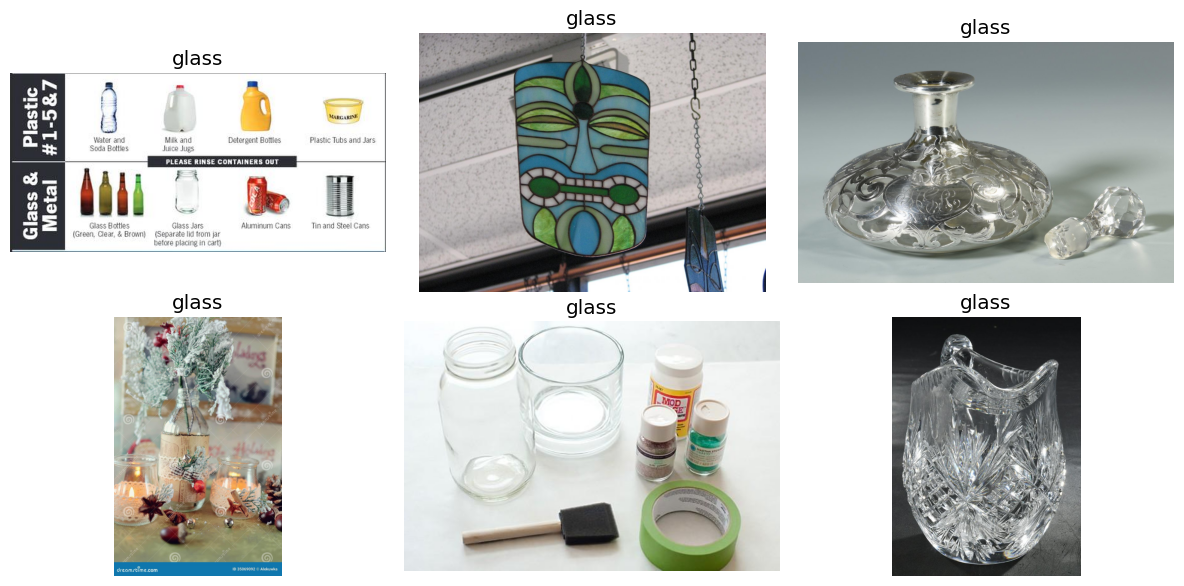

In [19]:
# Display sample images from the dataset
import matplotlib.pyplot as plt
from PIL import Image
import random

image_files = list(path.glob("*/*"))
sample_images = random.sample(image_files, 6)

plt.figure(figsize=(12, 6))

for i, img_path in enumerate(sample_images, 1):
    img = Image.open(img_path)

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.parent.name)

plt.tight_layout()
plt.show()

In [2]:
# Import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image settings
IMG_SIZE = 224
BATCH_SIZE = 16

# Training generator with augmentation
train_generator = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation generator without augmentation
val_generator = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [20]:
# Load training images
train_images = train_generator.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

# Load validation images
val_images = val_generator.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 116 images belonging to 2 classes.
Found 27 images belonging to 2 classes.


In [21]:
# Check class indices
print("Class indices:")
print(train_images.class_indices)

Class indices:
{'glass': 0, 'plastic': 1}


In [22]:
# Import TensorFlow and Keras layers
import tensorflow as tf
from tensorflow.keras import layers, models

In [23]:
# Build CNN model from scratch
cnn_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into one vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Dropout to reduce overfitting
    layers.Dropout(0.5),

    # Output layer for binary classification
    layers.Dense(1, activation="sigmoid")
])

# Show model architecture
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Compile CNN model
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [25]:
# Train CNN model
history_cnn = cnn_model.fit(
    train_images,
    validation_data=val_images,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4138 - loss: 1.5475 - val_accuracy: 0.5185 - val_loss: 0.7097
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5172 - loss: 0.6998 - val_accuracy: 0.5926 - val_loss: 0.6787
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5690 - loss: 0.6922 - val_accuracy: 0.6667 - val_loss: 0.6788
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6034 - loss: 0.6758 - val_accuracy: 0.5185 - val_loss: 0.6755
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6293 - loss: 0.6447 - val_accuracy: 0.5185 - val_loss: 0.7025
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6897 - loss: 0.6335 - val_accuracy: 0.6296 - val_loss: 0.7015
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6724 - loss: 0.6242 - val_accuracy: 0.4815 - val_loss: 0.7813
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6724 - loss: 0.5956 - val_accuracy: 0.6667 - val_loss: 0.7419
Epoch 9/

In [26]:
# Evaluate CNN model on validation data
cnn_loss, cnn_accuracy = cnn_model.evaluate(val_images)

print("CNN Validation Loss:", cnn_loss)
print("CNN Validation Accuracy:", cnn_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 837ms/step - accuracy: 0.4815 - loss: 0.7455
CNN Validation Loss: 0.7454943060874939
CNN Validation Accuracy: 0.48148149251937866


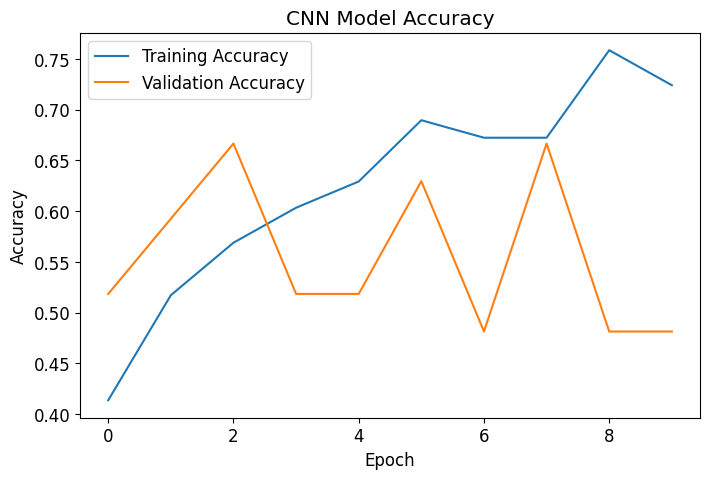

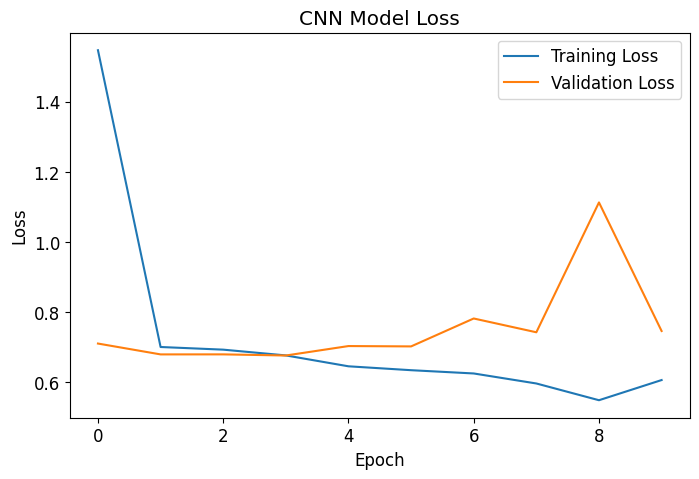

In [27]:
# Plot CNN training and validation accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot CNN training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [28]:
# Build a smaller CNN model to reduce overfitting
cnn_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,809 (108.63 KB)

 Trainable params: 27,809 (108.63 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [30]:
history_cnn = cnn_model.fit(
    train_images,
    validation_data=val_images,
    epochs=15
)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4828 - loss: 0.7008 - val_accuracy: 0.4815 - val_loss: 0.6933
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 983ms/step - accuracy: 0.4914 - loss: 0.6919 - val_accuracy: 0.4815 - val_loss: 0.6931
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 779ms/step - accuracy: 0.4828 - loss: 0.6930 - val_accuracy: 0.4815 - val_loss: 0.6929
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4569 - loss: 0.6959 - val_accuracy: 0.4815 - val_loss: 0.6928
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 815ms/step - accuracy: 0.5431 - loss: 0.6880 - val_accuracy: 0.4815 - val_loss: 0.6928
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 947ms/step - accuracy: 0.5086 - loss: 0.6945 - val_accuracy: 0.4815 - val_loss: 0.6926
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 914ms/step - accuracy: 0.5259 - loss: 0.6880 - val_accuracy: 0.4815 - val_loss: 0.6923
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 836ms/step - accuracy: 0.4483 - loss: 0.6972 - val_accuracy: 0.4815 - val_loss: 0.69

In [31]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(val_images)

print("CNN Validation Loss:", cnn_loss)
print("CNN Validation Accuracy:", cnn_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.4815 - loss: 0.6896
CNN Validation Loss: 0.6895580887794495
CNN Validation Accuracy: 0.48148149251937866


In [32]:
# Import MobileNetV2 pre-trained model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [33]:
# Data generators for MobileNetV2
mobilenet_train_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

mobilenet_val_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [34]:
# Load MobileNetV2 training images
mobilenet_train_images = mobilenet_train_generator.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

# Load MobileNetV2 validation images
mobilenet_val_images = mobilenet_val_generator.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("Class indices:")
print(mobilenet_train_images.class_indices)

Found 116 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
Class indices:
{'glass': 0, 'plastic': 1}


In [35]:
# Load MobileNetV2 base model
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base model layers
base_model.trainable = False

# Build transfer learning model
mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [36]:
# Compile MobileNetV2 model
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [37]:
# Callbacks to improve training
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=0.000001
)

In [38]:
# Train MobileNetV2 model
history_mobilenet = mobilenet_model.fit(
    mobilenet_train_images,
    validation_data=mobilenet_val_images,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4914 - loss: 1.0211 - val_accuracy: 0.4074 - val_loss: 0.7961 - learning_rate: 1.0000e-04
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 920ms/step - accuracy: 0.5086 - loss: 0.8850 - val_accuracy: 0.4815 - val_loss: 0.7595 - learning_rate: 1.0000e-04
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 818ms/step - accuracy: 0.6552 - loss: 0.7447 - val_accuracy: 0.5926 - val_loss: 0.7287 - learning_rate: 1.0000e-04
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 743ms/step - accuracy: 0.6810 - loss: 0.6088 - val_accuracy: 0.5926 - val_loss: 0.6967 - learning_rate: 1.0000e-04
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 953ms/step - accuracy: 0.6897 - loss: 0.6382 - val_accuracy: 0.6296 - val_loss: 0.6726 - learning_rate: 1.0000e-04
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 755ms/step - accuracy: 0.7155 - loss: 0.6146 - val_accuracy: 0.6667 - val_loss: 0.6497 - learning_rate: 1.0000e-04
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 918ms/step - accuracy: 0.7759 - loss: 

In [39]:
# Evaluate MobileNetV2 model
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(mobilenet_val_images)

print("MobileNetV2 Validation Loss:", mobilenet_loss)
print("MobileNetV2 Validation Accuracy:", mobilenet_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 524ms/step - accuracy: 0.7037 - loss: 0.6225
MobileNetV2 Validation Loss: 0.6224715709686279
MobileNetV2 Validation Accuracy: 0.7037037014961243


In [40]:
# Fine-tune the last layers of MobileNetV2
base_model.trainable = True

# Freeze most layers and train only the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a very small learning rate
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Continue training with fine-tuning
history_finetune = mobilenet_model.fit(
    mobilenet_train_images,
    validation_data=mobilenet_val_images,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7155 - loss: 0.6165 - val_accuracy: 0.7407 - val_loss: 0.6139 - learning_rate: 1.0000e-05
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7672 - loss: 0.4687 - val_accuracy: 0.7037 - val_loss: 0.6078 - learning_rate: 1.0000e-05
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 981ms/step - accuracy: 0.7069 - loss: 0.5703 - val_accuracy: 0.7407 - val_loss: 0.6004 - learning_rate: 1.0000e-05
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 993ms/step - accuracy: 0.7672 - loss: 0.4650 - val_accuracy: 0.7407 - val_loss: 0.5944 - learning_rate: 1.0000e-05
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7672 - loss: 0.4722 - val_accuracy: 0.7407 - val_loss: 0.5898 - learning_rate: 1.0000e-05
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8103 - loss: 0.4279 - val_accuracy: 0.7407 - val_loss: 0.5867 - learning_rate: 1.0000e-05
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 988ms/step - accuracy: 0.8017 - loss: 0.4011 - 

In [41]:
# Evaluate fine-tuned MobileNetV2 model
finetuned_loss, finetuned_accuracy = mobilenet_model.evaluate(mobilenet_val_images)

print("Fine-tuned MobileNetV2 Validation Loss:", finetuned_loss)
print("Fine-tuned MobileNetV2 Validation Accuracy:", finetuned_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step - accuracy: 0.7407 - loss: 0.5768
Fine-tuned MobileNetV2 Validation Loss: 0.5767804384231567
Fine-tuned MobileNetV2 Validation Accuracy: 0.7407407164573669


In [42]:
# Create comparison table
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "CNN from Scratch",
        "MobileNetV2",
        "Fine-tuned MobileNetV2"
    ],
    "Validation Loss": [
        cnn_loss,
        mobilenet_loss,
        finetuned_loss
    ],
    "Validation Accuracy": [
        cnn_accuracy,
        mobilenet_accuracy,
        finetuned_accuracy
    ]
})

display(comparison_df)

,Model,Validation Loss,Validation Accuracy
0,CNN from Scratch,0.689558,0.481481
1,MobileNetV2,0.622472,0.703704
2,Fine-tuned MobileNetV2,0.576780,0.740741


In [43]:
# Classification report for Fine-tuned MobileNetV2
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mobilenet_val_images.reset()

predictions = mobilenet_model.predict(mobilenet_val_images)
predicted_classes = (predictions > 0.5).astype("int32").flatten()

true_classes = mobilenet_val_images.classes
class_names = list(mobilenet_val_images.class_indices.keys())

print("Fine-tuned MobileNetV2 Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step
Fine-tuned MobileNetV2 Classification Report:
              precision    recall  f1-score   support

       glass       0.71      0.86      0.77        14
     plastic       0.80      0.62      0.70        13

    accuracy                           0.74        27
   macro avg       0.75      0.74      0.73        27
weighted avg       0.75      0.74      0.74        27



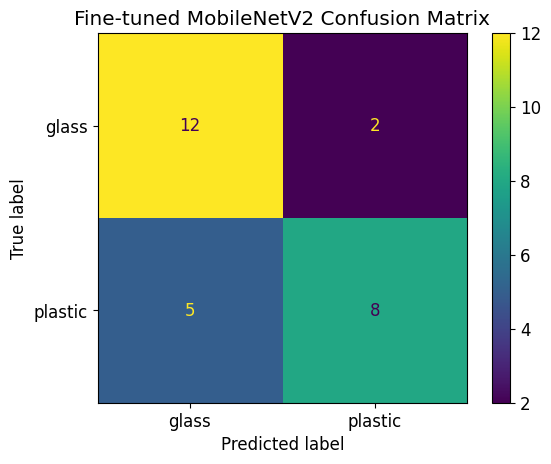

In [44]:
# Confusion matrix for Fine-tuned MobileNetV2
cm = confusion_matrix(true_classes, predicted_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Fine-tuned MobileNetV2 Confusion Matrix")
plt.show()

In [45]:
# Final results summary
print("Final Model Comparison")
print("----------------------")
print("CNN Validation Accuracy:", round(cnn_accuracy, 4))
print("MobileNetV2 Validation Accuracy:", round(mobilenet_accuracy, 4))
print("Fine-tuned MobileNetV2 Validation Accuracy:", round(finetuned_accuracy, 4))

print("\nBest Model: Fine-tuned MobileNetV2")

Final Model Comparison
----------------------
CNN Validation Accuracy: 0.4815
MobileNetV2 Validation Accuracy: 0.7037
Fine-tuned MobileNetV2 Validation Accuracy: 0.7407

Best Model: Fine-tuned MobileNetV2


In [46]:
# Save the best model
mobilenet_model.save("best_glass_plastic_mobilenet_model.keras")

print("Best Fine-tuned MobileNetV2 model saved successfully.")

Best Fine-tuned MobileNetV2 model saved successfully.
